1.
Simulate the forward diffusion process by writing a Python function that takes a grayscale image (use any small PNG or JPEG) and adds Gaussian noise to it for 10 steps, saving each noisy image to disk.

In [4]:
pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

Created a placeholder 'input.jpg' since none was found.


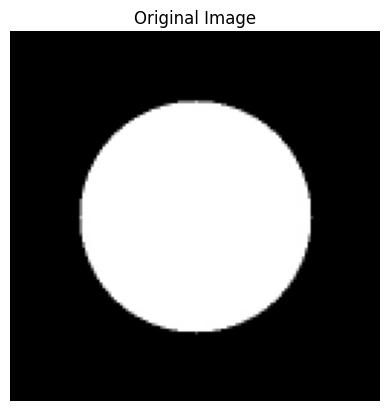

In [8]:
# Check if input.jpg exists, otherwise create a placeholder grayscale image
if not os.path.exists('input.jpg'):
    # Generate a dummy image: a white circle on a black background
    dummy = np.zeros((256, 256), dtype=np.uint8)
    cv2.circle(dummy, (128, 128), 80, 255, -1)
    cv2.imwrite('input.jpg', dummy)
    print("Created a placeholder 'input.jpg' since none was found.")

# Load image in grayscale mode
image = cv2.imread('input.jpg', cv2.IMREAD_GRAYSCALE)

# Resize image (optional)
image = cv2.resize(image, (128, 128))

# Normalize pixel values
image = image.astype(np.float32) / 255.0

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


In [9]:
os.makedirs("forward_diffusion", exist_ok=True)

In [10]:
def add_noise(image, step, total_steps=10):

    beta = step / total_steps

    noise = np.random.normal(
        loc=0,
        scale=np.sqrt(beta),
        size=image.shape
    )

    noisy_image = image + noise

    noisy_image = np.clip(noisy_image, 0, 1)

    return noisy_image

In [11]:
current_image = image.copy()

for step in range(1, 11):

    current_image = add_noise(current_image, step)

    save_img = (current_image * 255).astype(np.uint8)

    cv2.imwrite(
        f'forward_diffusion/noisy_step_{step}.png',
        save_img
    )

    print(f"Saved noisy_step_{step}.png")

Saved noisy_step_1.png
Saved noisy_step_2.png
Saved noisy_step_3.png
Saved noisy_step_4.png
Saved noisy_step_5.png
Saved noisy_step_6.png
Saved noisy_step_7.png
Saved noisy_step_8.png
Saved noisy_step_9.png
Saved noisy_step_10.png


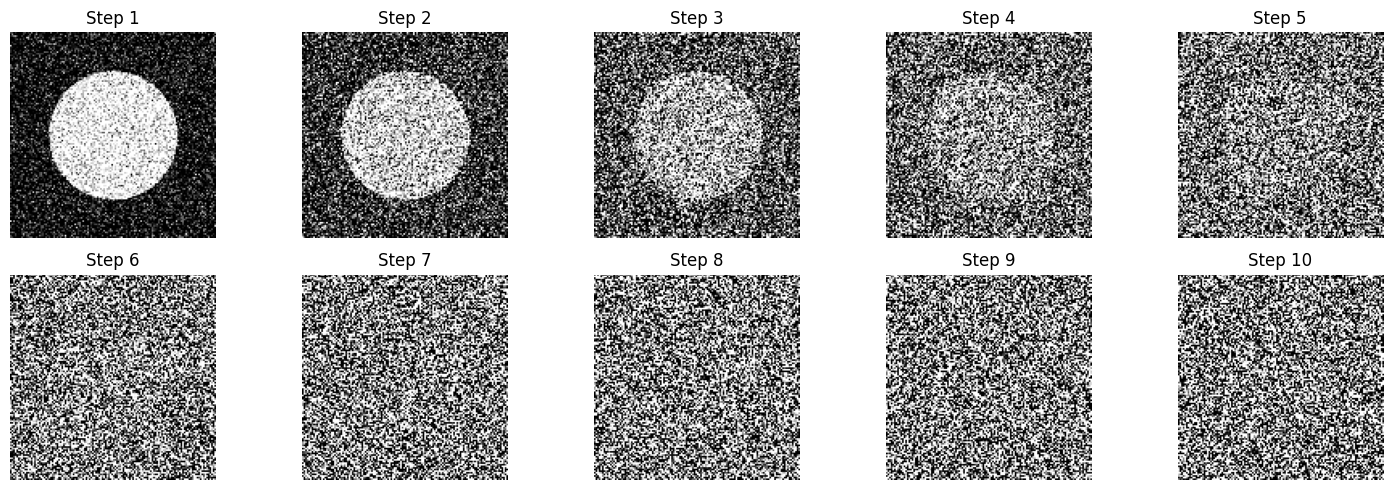

In [12]:
plt.figure(figsize=(15,5))

for i in range(10):

    img = cv2.imread(
        f'forward_diffusion/noisy_step_{i+1}.png',
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Step {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

2.
Write a Python script that takes a noisy image and applies a simple denoising filter (like median blur or Gaussian blur) to approximate the reverse diffusion process, then compare the denoised output visually with the original image.

In [13]:
original = cv2.imread(
    'input.jpg',
    cv2.IMREAD_GRAYSCALE
)

noisy = cv2.imread(
    'forward_diffusion/noisy_step_10.png',
    cv2.IMREAD_GRAYSCALE
)

In [14]:
denoised = cv2.medianBlur(noisy, 5)

# Alternative:
# denoised = cv2.GaussianBlur(noisy, (5,5), 0)

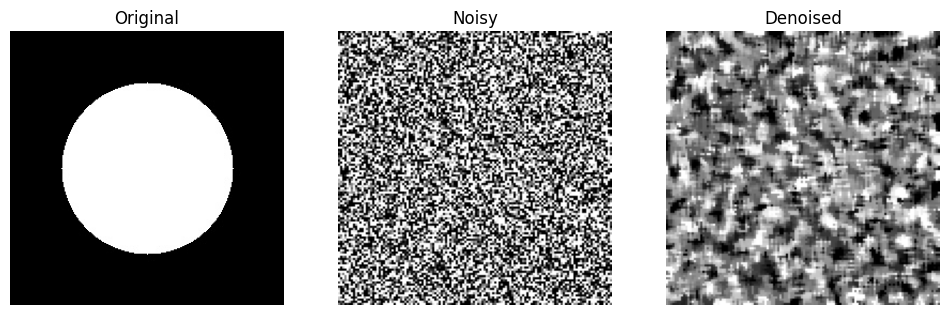

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.axis('off')

plt.show()

3. Use the Stable Diffusion web demo (https://stablediffusionweb.com/ or similar) to generate an image from the text prompt: 'A futuristic cricket stadium during IPL finals, night view, neon lights'. Save the generated image and write 2-3 lines describing how the AI interpreted your prompt.

The AI generated a large futuristic cricket stadium illuminated with bright neon lights under a night sky. The stadium featured advanced architectural elements, vibrant lighting effects, and a packed audience, creating a grand IPL final atmosphere. The model interpreted the "futuristic" aspect by adding modern structures, glowing visuals, and high-tech design elements.


Task 4: Real-World Applications Using Diffusion Models

Application
Adobe Photoshop	
Users can remove unwanted objects from photos or extend image backgrounds using Generative Fill. Diffusion models intelligently fill missing regions while preserving realism.
Topaz Photo AI	
Photographers use Topaz Photo AI to upscale low-resolution images and improve sharpness. Diffusion-based super-resolution techniques reconstruct detailed high-quality images from blurry or small photos.

Task 5: Risks and Ethical Concerns


Risk/Ethical Concern
Creation of misleading or fake images (deepfakes) that spread misinformation on social media.

Mitigation Strategy
Developers can add visible or invisible watermarks and implement AI-generated content detection systems.

Risk/Ethical Concern
Generation of harmful, offensive, or copyrighted content.	

Mitigation Strategy

Developers can apply content moderation filters, safety classifiers, and block harmful prompts during image generation.